In [299]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [300]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors

In [301]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

In [302]:
rot = False
u = 10

dycore = 'se'
#res = 'ne30'
res = 'ne60'

lev_no1 = 'ztop20km_L56'
lev_no2 = 'ztop20km_L56'
lev_no3 = 'ztop20km_L56'

#lev_no1 = 'ztop20km_L43'
#lev_no2 = 'ztop20km_L45'
#lev_no3 = 'ztop20km_L52'

extra_name1 = 'h0_1500_tau_1_2'
extra_name2 = 'h0_2000_tau_1_2'
extra_name3 = 'h0_2000_tau_1_2'


CAM_branch = 'CAM_6_4_100_11082025'

test_name_start = 'cam_6_4_100'

case1 = f'{test_name_start}_{dycore}_{res}_{lev_no1}'
case2 = f'{test_name_start}_{dycore}_{res}_{lev_no2}'
case3 = f'{test_name_start}_{dycore}_{res}_{lev_no3}'


# Compare three files
if rot:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_vortex_with_rot_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_vortex_with_rot_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_vortex_with_rot_{extra_name3}'
else:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_vortex_omega0_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_vortex_omega0_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_vortex_omega0_{extra_name3}'

if dycore ==  'fv3':
    nc_file1 = f'{nc_file1}.regrid.1x1'

nc_file1 = nc_file1 + '.nc'
nc_file2 = nc_file2 + '.nc'
nc_file3 = nc_file3 + '.nc'

In [303]:
run_base = "/glade/derecho/scratch/timand/"

run_path1 = run_base + case1 + '/run/' + nc_file1
run_path2 = run_base + case2 + '/run/' + nc_file2
run_path3 = run_base + case3 + '/run/' + nc_file3

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)
nc3 = Dataset(run_path3)

In [304]:
time = nc1['time'][:]
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 

In [305]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat
lat_crop_up = 60.
lat_cent_down = -20.

lon_crop_left = 60.
lon_crop_right = 270.

lat_ticks = np.linspace(0, 40, 5)
lon_ticks = np.linspace(60, 225, 6)

lon_inds = np.where((lon < lon_crop_right) & (lon > lon_crop_left))[0]
lat_inds = np.where((lat < lat_crop_up) & (lat > lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)

In [306]:
# Field to compare
field = 'U'

# Time index to compare at
t_idx = 80

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

# Choice of colormap
# Choice of colormap
if field == 'T':        
    cmap_choice = 'jet'
else:
    cmap_choice = 'seismic'
    #cmap_choice='jet'

In [307]:
# Interpolations:
field_vals1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1[field][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
field_vals2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2[field][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
field_vals3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3[field][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

In [308]:
deg2rad = np.pi/180
T0 = 288

if field == 'U':
    # Normalised velocity perturbation:
        field_vals1 = (field_vals1 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals2 = (field_vals2 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals3 = (field_vals3 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
else:
    # Temperature perturbation:
        field_vals1 = field_vals1 - T0
        field_vals2 = field_vals2 - T0
        field_vals3 = field_vals3 - T0

min value is -1.6649260568425517
max value is 0.7731608079616274


Text(0.5, 0.01, 'Longitude (deg)')

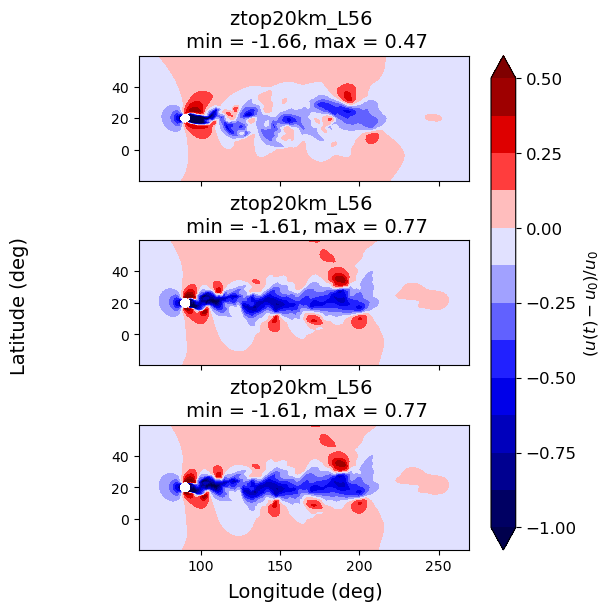

In [309]:
title_size=16
label_size=14
small_size=12

max1 = np.nanmax(field_vals1)
max2 = np.nanmax(field_vals2)
max3 = np.nanmax(field_vals3)

min1 = np.nanmin(field_vals1)
min2 = np.nanmin(field_vals2)
min3 = np.nanmin(field_vals3)

maxmax = max(max1, max2, max3)
minmin = min(min1, min2, min3)

print('min value is', minmin)
print('max value is', maxmax)

conts = np.linspace(minmin, maxmax, 21)

fig, axes = plt.subplots(3,1, sharex=True, figsize = (6,6), layout="constrained")
(ax1, ax2, ax3) = axes

if field == 'T':
    if rot:
        conts = np.linspace(-1, 3, 7)
        norm = colors.Normalize(vmin=-1, vmax=3)
        tick_range = np.linspace(-1, 3, 7)
    else:
        conts = np.linspace(-1, 2, 7)
        norm = colors.Normalize(vmin=-1, vmax=2)
        tick_range = np.linspace(-1, 2, 7)
    plot1 = ax1.contourf(LON, LAT, field_vals1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot2 = ax2.contourf(LON, LAT, field_vals2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot3 = ax3.contourf(LON, LAT, field_vals3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    title = 'Temperature perturbation'
    cb_label = 'T - T0 (K)'
else:
    if rot:
        conts = np.linspace(-2.0, 2.0, 9)
        tick_range = np.linspace(-2.0, 2.0, 9)
        norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)
    else:
        conts = np.linspace(-1, 0.5, 13)
        tick_range = np.linspace(-1, 0.5, 7)
        norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=0.5)
    plot1 = ax1.contourf(LON, LAT, field_vals1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot2 = ax2.contourf(LON, LAT, field_vals2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot3 = ax3.contourf(LON, LAT, field_vals3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    title = 'Normalised velocity perturbation'
    cb_label = '$(u(t) - u_0)/u_0$'

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')

cb = plt.colorbar(plot3, ax=axes, ticks = tick_range, fraction=0.4)
cb.set_label(label=cb_label, size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{lev_no1} \n min = {np.round(min1,2)}, max = {np.round(max1,2)}', size=label_size)
ax2.set_title(f'{lev_no2} \n min = {np.round(min2,2)}, max = {np.round(max2,2)}', size=label_size)
ax3.set_title(f'{lev_no3} \n min = {np.round(min3,2)}, max = {np.round(max3,2)}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

In [310]:
# Velocity interpolation for relative vorticity

t_idx = 80

# z_val = z_val
z_val = 500

u1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
u2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
u3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

v1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['V'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
v2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['V'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
v3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3['V'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

In [311]:
# Plot the relative vorticity:
# This should be the most elucidating ...

#field_vals1 = mpcalc.vorticity(u1, v1, lon_crop, lat_crop)
#field_vals2 = mpcalc.vorticity(u2['U'], u2['V'])
#field_vals3 = mpcalc.vorticity(u3['U'], u3['V'])

uv_ds1 = xr.Dataset(data_vars = dict(
        U=(['lat', 'lon'], u1), V=(['lat', 'lon'], v1)), coords = dict(time=time[t_idx], lat=lat_crop, lon=lon_crop))
uv_ds1['U'].attrs["units"] = "m/s"
uv_ds1['V'].attrs["units"] = "m/s"
field_vals1 = mpcalc.vorticity(uv_ds1['U'], uv_ds1['V'])

uv_ds2 = xr.Dataset(data_vars = dict(
        U=(['lat', 'lon'], u2), V=(['lat', 'lon'], v2)), coords = dict(time=time[t_idx], lat=lat_crop, lon=lon_crop))
uv_ds2['U'].attrs["units"] = "m/s"
uv_ds2['V'].attrs["units"] = "m/s"
field_vals2 = mpcalc.vorticity(uv_ds2['U'], uv_ds2['V'])

uv_ds3 = xr.Dataset(data_vars = dict(
        U=(['lat', 'lon'], u3), V=(['lat', 'lon'], v3)), coords = dict(time=time[t_idx], lat=lat_crop, lon=lon_crop))
uv_ds3['U'].attrs["units"] = "m/s"
uv_ds3['V'].attrs["units"] = "m/s"
field_vals3 = mpcalc.vorticity(uv_ds3['U'], uv_ds3['V'])

min value is -0.0001337497251562135
max value is 0.00012296119705909378


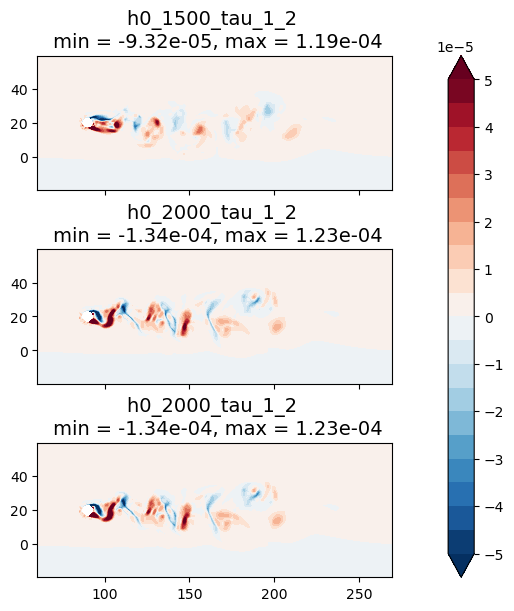

In [312]:

cmap_choice = 'RdBu_r'

max1 = np.nanmax(field_vals1)
max2 = np.nanmax(field_vals2)
max3 = np.nanmax(field_vals3)

min1 = np.nanmin(field_vals1)
min2 = np.nanmin(field_vals2)
min3 = np.nanmin(field_vals3)

maxmax = max(max1, max2, max3)
minmin = min(min1, min2, min3)
absmax = 5e-5
#absmax = max(abs(minmin),abs(maxmax))

print('min value is', minmin)
print('max value is', maxmax)

conts = np.linspace(-absmax, absmax, 21)
tick_range = np.linspace(-absmax, absmax, 11)
norm = colors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

fig, axes = plt.subplots(3,1, sharex=True, figsize = (10,6), layout="constrained")
(ax1, ax2, ax3) = axes

plot1 = ax1.contourf(LON, LAT, field_vals1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, field_vals2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
plot3 = ax3.contourf(LON, LAT, field_vals3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')

ax1.set_title(f'{extra_name1} \n min = {min1:.2e}, max = {max1:.2e}', size=label_size)
ax2.set_title(f'{extra_name2} \n min = {min2:.2e}, max = {max2:.2e}', size=label_size)
ax3.set_title(f'{extra_name3} \n min = {min3:.2e}, max = {max3:.2e}', size=label_size)

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')

cb = plt.colorbar(plot3, ax=axes, ticks = tick_range, fraction=0.4)

In [313]:
# Geopotential height:
print(nc1['Z3'][0, :, 0, 0])

# Height in isothermal atmosphere:
p = nc1['lev'][:]*100
p0 = 1e5
H = 287.04*288/9.80616
z = H*np.log(p0/p)
print(z)

# Ah, so these are very similar, but not exactly the same.

[19997.252    19497.395    18997.537    18497.68     17997.822
 17497.965    16998.107    16498.25     15998.393    15498.535
 14998.678    14498.82     13998.963    13499.105    12999.248
 12499.39     11999.532    11499.675    10999.817    10499.96
 10000.103     9500.245     9000.388     8500.53      8000.6724
  7500.815     7000.9575    6501.1       6001.2427    5501.3853
  5001.5273    4505.796     4042.305     3631.3708    3266.177
  2940.8823    2650.4717    2390.6272    2157.6255    1948.2463
  1759.7003    1589.5657    1435.7347    1296.3702    1169.867
  1054.82       949.9965     849.9969     749.99725    649.9976
   549.998      449.99835    349.99872    249.99908    149.99945
    49.999817]
[19998.33620146747 19498.33620146747 18998.336201467468 18498.33620146747
 17998.336201467468 17498.33620146747 16998.336201467468
 16498.336201467468 15998.33620146747 15498.336201467468
 14998.336201467468 14498.336201467466 13998.336201467468
 13498.336201467468 12998.33620146747 124